# __Hometask__

1. Load the **Electricity Consumption data** in Romania (`./datasets/electricity_consumption_and_production.csv`). Use the `Consumption` column as the target variable.
2. Perform **EDA**: decompose the series, plot ACF and PACF, and run the ADF stationarity test. Note that the data contains **hourly observations** — resample to daily before performing forecast.
3. Clean data if necessary.
4. Train forecasting models (Use models from the lecture or other ones if you wish) and produce forecasts for **15, 30, and 45 days ahead**.
5. Visualize predictions and provide evaluation metrics

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

In [2]:
datapath = os.path.join("data", "electricity_consumption_and_production.csv")
df = pd.read_csv(datapath)

In [3]:
df.head()

,DateTime,Consumption,Production,Nuclear,Wind,Hydroelectric,Oil and Gas,Coal,Solar,Biomass
0,2019-01-01 00:00:00,6352,6527,1395,79,1383,1896,1744,0,30
1,2019-01-01 01:00:00,6116,5701,1393,96,1112,1429,1641,0,30
2,2019-01-01 02:00:00,5873,5676,1393,142,1030,1465,1616,0,30
3,2019-01-01 03:00:00,5682,5603,1397,191,972,1455,1558,0,30
4,2019-01-01 04:00:00,5557,5454,1393,159,960,1454,1458,0,30


In [4]:
y = df[["DateTime","Consumption"]]


In [5]:
y.head()

,DateTime,Consumption
0,2019-01-01 00:00:00,6352
1,2019-01-01 01:00:00,6116
2,2019-01-01 02:00:00,5873
3,2019-01-01 03:00:00,5682
4,2019-01-01 04:00:00,5557


In [6]:
y[y["DateTime"].duplicated()]

,DateTime,Consumption
7177,2019-10-27 03:00:00,5196
7178,2019-10-27 03:00:00,5196
15914,2020-10-25 03:00:00,5220
15915,2020-10-25 03:00:00,5220
24819,2021-10-31 03:00:00,5341
24820,2021-10-31 03:00:00,5341
33556,2022-10-30 03:00:00,4503
33557,2022-10-30 03:00:00,4503
42293,2023-10-29 03:00:00,4607
50946,2024-10-27 03:00:00,5073


In [7]:
y = y.drop_duplicates(["DateTime"])
y.duplicated().any()

np.False_

In [8]:
y["DateTime"] = pd.to_datetime(y["DateTime"])
y = y.set_index("DateTime")

In [9]:
target = y["Consumption"].resample("D").sum()
target[-5:]

DateTime
2025-03-15    133813
2025-03-16    128313
2025-03-17    158475
2025-03-18    161598
2025-03-19    143281
Freq: D, Name: Consumption, dtype: int64

<Axes: xlabel='DateTime'>

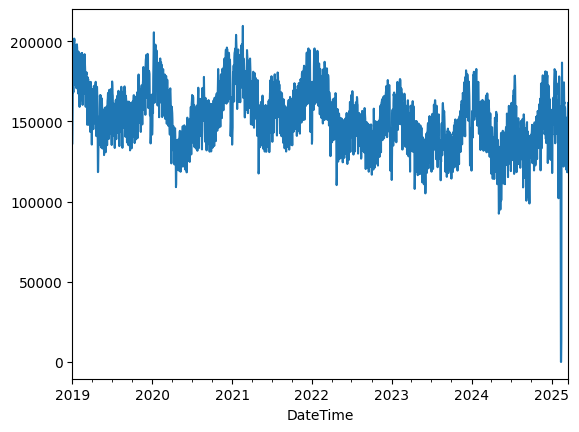

In [10]:
target.plot()   

In [11]:
target[target<80000]

DateTime
2025-02-12    61192
2025-02-13        0
2025-02-14        0
2025-02-15    13140
Freq: D, Name: Consumption, dtype: int64

In [12]:
target.loc["2025-02-12":"2025-02-15"] = np.nan

Those 4 records looks like an error to me, so i interpolate them

In [13]:
target = target.interpolate(method="time")

<Axes: xlabel='DateTime'>

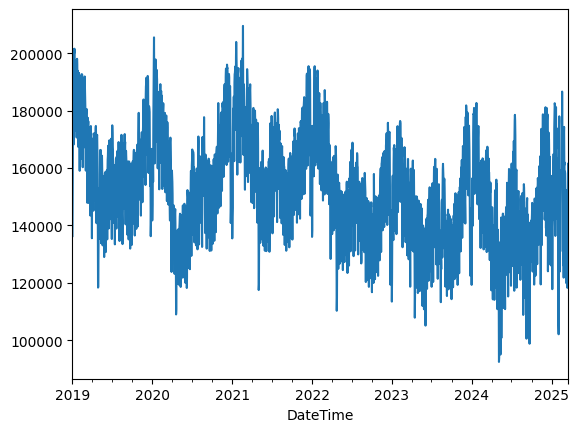

In [14]:
target.plot()

In [15]:
from statsmodels.tsa.seasonal import seasonal_decompose


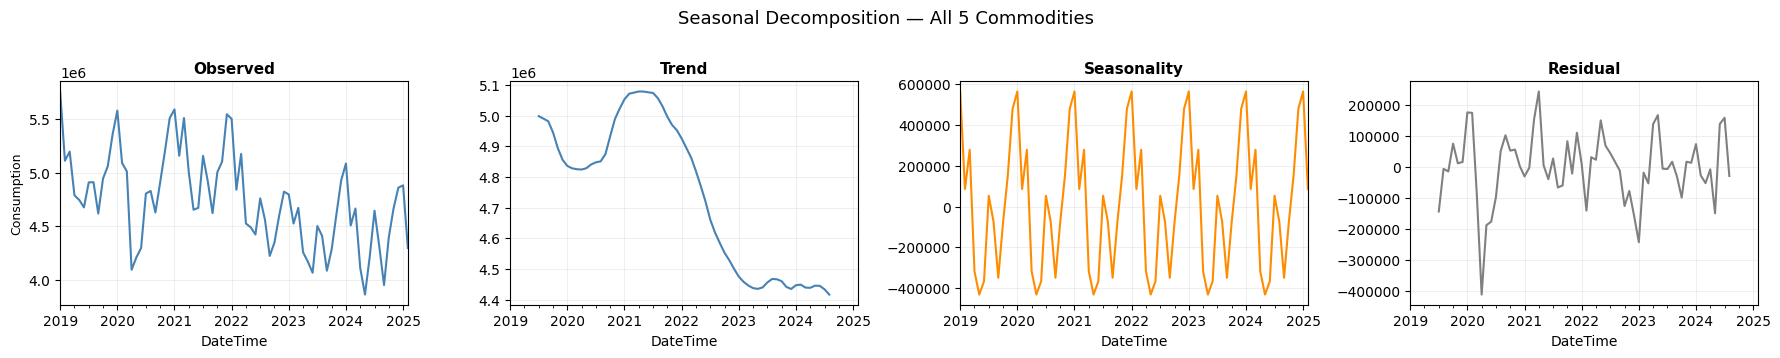

In [16]:
fig, axes = plt.subplots(1, 4, figsize=(18, 3.5))
component_titles = ["Observed", "Trend", "Seasonality", "Residual"]
graph_target = target.loc["2019-01-01":"2025-02-28"]

decomp = seasonal_decompose(graph_target.resample("ME").sum(), model="additive", period=12)
components = [decomp.observed, decomp.trend, decomp.seasonal, decomp.resid]
for col, (comp, ctitle) in enumerate(zip(components, component_titles)):
    comp.plot(ax=axes[col], color="steelblue" if col < 2 else "darkorange" if col == 2 else "gray")
    axes[ col].set_title(ctitle, fontsize=11, fontweight="bold")
    if col == 0:
        axes[col].set_ylabel("Consumption"[:16], fontsize=9)
    axes[col].grid(True, alpha=0.2)
plt.suptitle("Seasonal Decomposition — All 5 Commodities", fontsize=13, y=1.01)
plt.tight_layout()

I showed decomposition in monthly, because otherwise seasonality becomes filled square, cons of it is because of that the graphs look kinda bad on the right end, because last info we have is only to 19th, so last month is not full and so i excluded it from the graph

So far we see that the consuption had a big leap down and stayed like that, and seasonality shows us that in winter consumption is bigger, and in summer is smaller

In [17]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

Text(0.5, 0, 'Lag (months)')

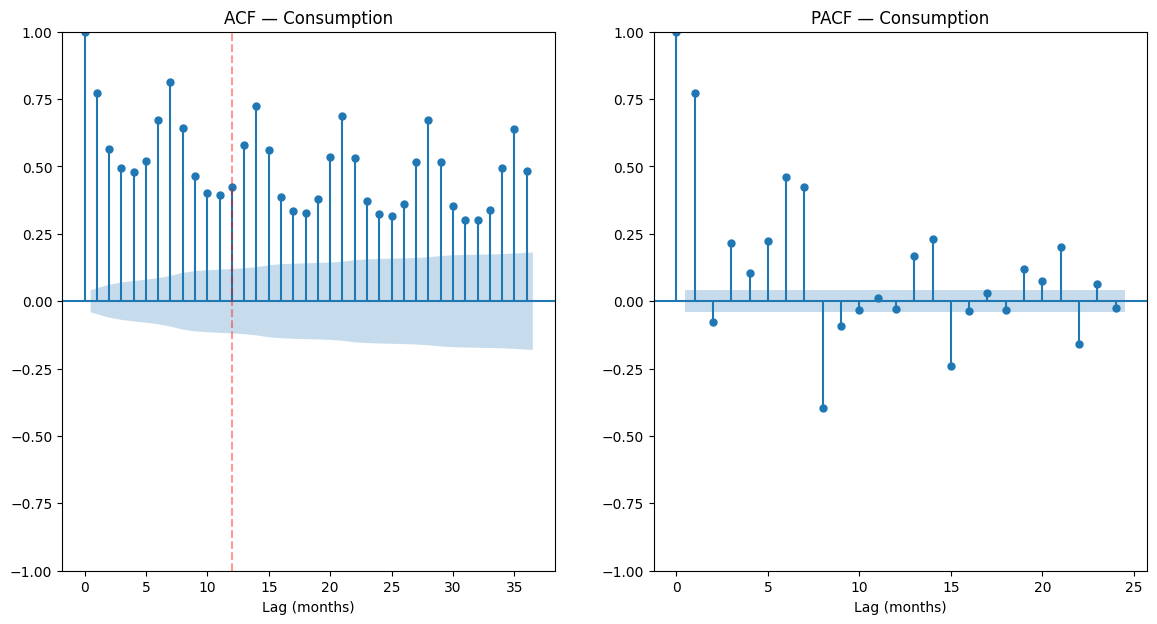

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 7))

plot_acf(target, lags=36, ax=axes[0], title=f"ACF — Consumption")
axes[0].axvline(x=12, color="red", linestyle="--", alpha=0.4)
axes[0].set_xlabel("Lag (months)")

plot_pacf(target, lags=24, method="ywm", ax=axes[1], title=f"PACF — Consumption")
axes[1].set_xlabel("Lag (months)")


In [19]:
from statsmodels.tsa.stattools import adfuller


In [20]:
def adf_stationarity_test(series: pd.Series) -> dict:
    result = adfuller(series)
    p_value = result[1]
    return {"ADF Statistic": round(result[0], 4), "p-value": round(p_value, 4),
            "Stationary": p_value < 0.05}

In [21]:
adf_stationarity_test(target)

{'ADF Statistic': np.float64(-3.1786),
 'p-value': np.float64(0.0213),
 'Stationary': np.True_}

Now let's train some models!

In [22]:
from darts import TimeSeries
from darts.metrics import mae, mape, mse, mql
import optuna
optuna.logging.set_verbosity(optuna.logging.ERROR)

In [23]:
# Convert all 5 commodities to darts TimeSeries
consumption_series = TimeSeries.from_series(target, freq="D")

TEST_SIZE = 18*30  # ~18-month forecast horizon
train_split = consumption_series[:-TEST_SIZE]
val_split = consumption_series[-TEST_SIZE:]


The visualisation functions i took from the lecture and remade them for this usage case

In [24]:
def calculate_metrics(actual_ts, pred_ts, q_low=0.1, q_high=0.9):
    """Point + probabilistic metrics for a single-series forecast."""
    is_prob = pred_ts.n_samples > 1
    median = pred_ts.quantile(0.5) if is_prob else pred_ts
    return {
        "MAPE (%)": round(mape(actual_ts, median), 3),
        "MAE":      round(mae(actual_ts, median), 3),
        "MSE":      round(mse(actual_ts, median), 3),
        f"QL@{q_low}":  round(mql(actual_ts, pred_ts, q=q_low),  3) if is_prob else None,
        f"QL@{q_high}": round(mql(actual_ts, pred_ts, q=q_high), 3) if is_prob else None,
    }


def visualize_multi_forecast(model_name, prediction, q_low=0.1, q_high=0.9):
    """Plot forecasts for consumption in a subplot figure.

    prediction : darts TimeSeries (probabilistic)
    Returns     : metrics dict
    """
    fig, ax = plt.subplots(1, 1, figsize=(14, 7))

    is_prob   = prediction.n_samples > 1
    median    = prediction.quantile(0.5) if is_prob else prediction

    train_split.to_series().plot(ax=ax, label="Training data", color="steelblue", lw=1.8)
    val_split.to_series().plot(ax=ax, label="Actual values", color="green",    lw=1.8)
    median.to_series().plot(   ax=ax, label="Forecast (median)", color="tomato",    lw=1.8)

    if is_prob:
        low  = prediction.quantile(q_low).values()[:, 0]
        high = prediction.quantile(q_high).values()[:, 0]
        ax.fill_between(
            prediction.time_index, low, high,
            alpha=0.25, color="tomato",
            label=f"{int((1 - 2*q_low)*100)}% CI"
        )

    ax.set_title(f"{model_name} — Consumption", fontsize=11, fontweight="bold")
    ax.set_ylabel("Consumption")
    ax.grid(True, alpha=0.3)
    ax.legend(loc="upper left", fontsize=8)

    metrics = calculate_metrics(val_split, prediction, q_low, q_high)

    summary = f"MAPE {metrics['MAPE (%)']:.1f}%  |  MAE {metrics['MAE']:.1f}"
    if metrics[f"QL@{q_low}"] is not None:
        summary += f"  |  QL@{q_low} {metrics[f'QL@{q_low}']:.1f}  QL@{q_high} {metrics[f'QL@{q_high}']:.1f}"
    ax.text(0.99, 0.97, summary, transform=ax.transAxes, fontsize=9,
            ha="right", va="top",
            bbox=dict(facecolor="white", alpha=0.8, edgecolor="gray", boxstyle="round,pad=0.4"))

    plt.tight_layout()
    plt.show()
    return metrics

In [25]:
forecast_lengths = [15, 30, 45]

Let's start with SARIMA

In [26]:
from darts.models import ARIMA

def sarima_objective(trial):
    p = trial.suggest_int("p", 0, 3)
    q = trial.suggest_int("q", 0, 3)
    P = trial.suggest_int("P", 0, 2)
    Q = trial.suggest_int("Q", 0, 2)
    try:
        model = ARIMA(p=p, d=0, q=q, seasonal_order=(P, 0, Q, 7))
        model.fit(train_split)
        pred = model.predict(n=len(val_split))
        return mape(val_split, pred)
    except Exception:
        return float("inf")

study_sarima = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=42))
study_sarima.optimize(sarima_objective, n_trials=20, show_progress_bar=True)
print(f"\nBest MAPE on 'Consumption': {study_sarima.best_value:.2f}%")
print(f"Best params: {study_sarima.best_params}")

  0%|          | 0/20 [00:00<?, ?it/s]

c:\Users\vital\Desktop\DSCamp\.venv2\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\vital\Desktop\DSCamp\.venv2\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\vital\Desktop\DSCamp\.venv2\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
c:\Users\vital\Desktop\DSCamp\.venv2\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\vital\De


Best MAPE on 'Consumption': 8.49%
Best params: {'p': 3, 'q': 2, 'P': 1, 'Q': 2}


I used seasonality 7, because data is in days, and i think 7 works the best for this case. And d, D set to 0 because of data stationarity

c:\Users\vital\Desktop\DSCamp\.venv2\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\vital\Desktop\DSCamp\.venv2\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
c:\Users\vital\Desktop\DSCamp\.venv2\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


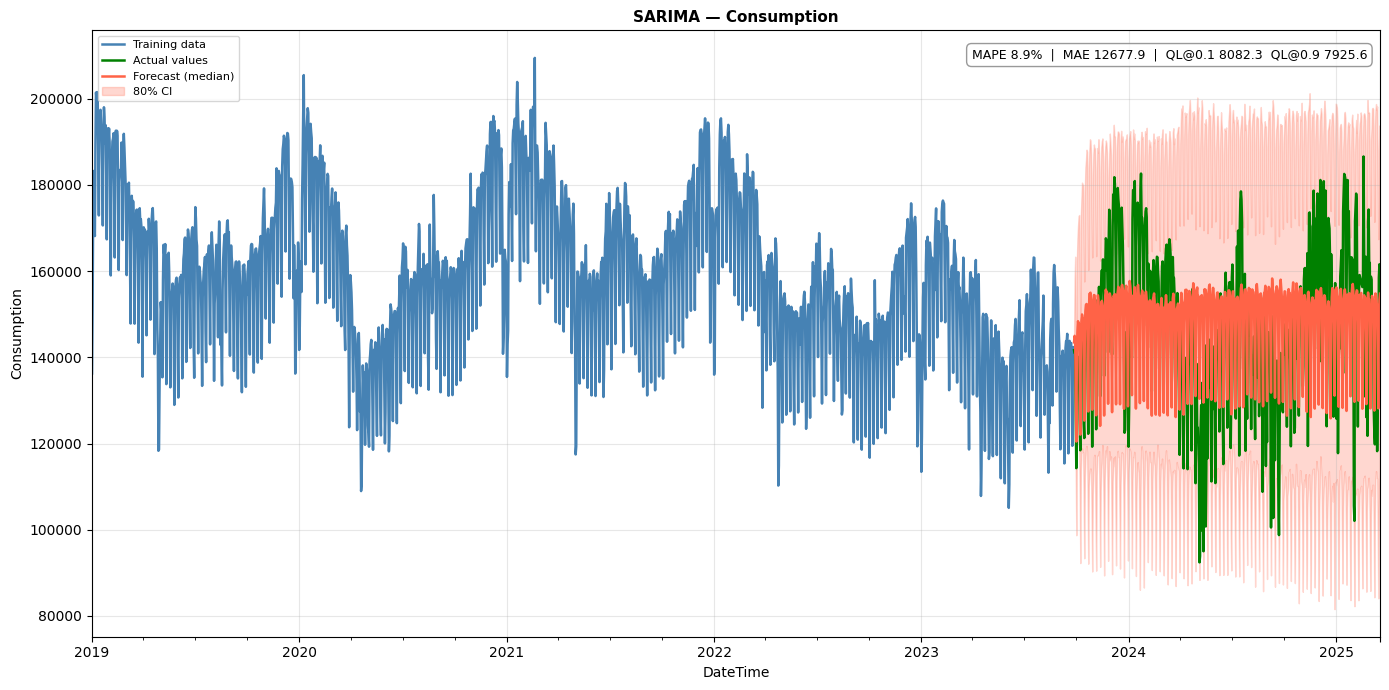

In [39]:
arima_bp = study_sarima.best_params
arima = ARIMA(p=arima_bp["p"], d=0, q=arima_bp["q"],
                  seasonal_order=(arima_bp["P"], 0, arima_bp["Q"], 7))
arima.fit(train_split)
sarima_predictions = arima.predict(n=TEST_SIZE, num_samples=500)
sarima_all_metrics = visualize_multi_forecast("SARIMA", sarima_predictions)


So on average model is wrong by 12200 units, ~8-9 percent miss

Next model is exponential smoothing

In [28]:
from darts.models import ExponentialSmoothing
from darts.utils.utils import ModelMode, SeasonalityMode

TREND_MAP    = {"additive": ModelMode.ADDITIVE, "multiplicative": ModelMode.MULTIPLICATIVE, "none": ModelMode.NONE}
SEASONAL_MAP = {"additive": SeasonalityMode.ADDITIVE, "multiplicative": SeasonalityMode.MULTIPLICATIVE}

def es_objective(trial):
    trend_str    = trial.suggest_categorical("trend",    ["additive", "multiplicative", "none"])
    seasonal_str = trial.suggest_categorical("seasonal", ["additive", "multiplicative"])
    damped       = trial.suggest_categorical("damped",   [True, False])
    if trend_str == "none" and damped:
        return float("inf")
    try:
        model = ExponentialSmoothing(
            trend=TREND_MAP[trend_str], seasonal=SEASONAL_MAP[seasonal_str],
            damped=damped, seasonal_periods=12,
        )
        model.fit(train_split)
        pred = model.predict(n=len(val_split))
        return mape(val_split, pred)
    except Exception:
        return float("inf")

study_es = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=42))
study_es.optimize(es_objective, n_trials=15, show_progress_bar=True)
print(f"\nBest MAPE on 'Consumption': {study_es.best_value:.2f}%")
print(f"Best params: {study_es.best_params}")

  0%|          | 0/15 [00:00<?, ?it/s]

c:\Users\vital\Desktop\DSCamp\.venv2\Lib\site-packages\statsmodels\tsa\holtwinters\model.py:85: RuntimeWarning: overflow encountered in matmul
  return err.T @ err



Best MAPE on 'Consumption': 10.11%
Best params: {'trend': 'multiplicative', 'seasonal': 'additive', 'damped': True}


In [46]:
es_bp = study_es.best_params
es = ExponentialSmoothing(
    trend=TREND_MAP[es_bp["trend"]], seasonal=SEASONAL_MAP[es_bp["seasonal"]],
    damped=es_bp["damped"], seasonal_periods=7,
    )
es.fit(train_split)
es_predictions = es.predict(n=TEST_SIZE, num_samples=500)


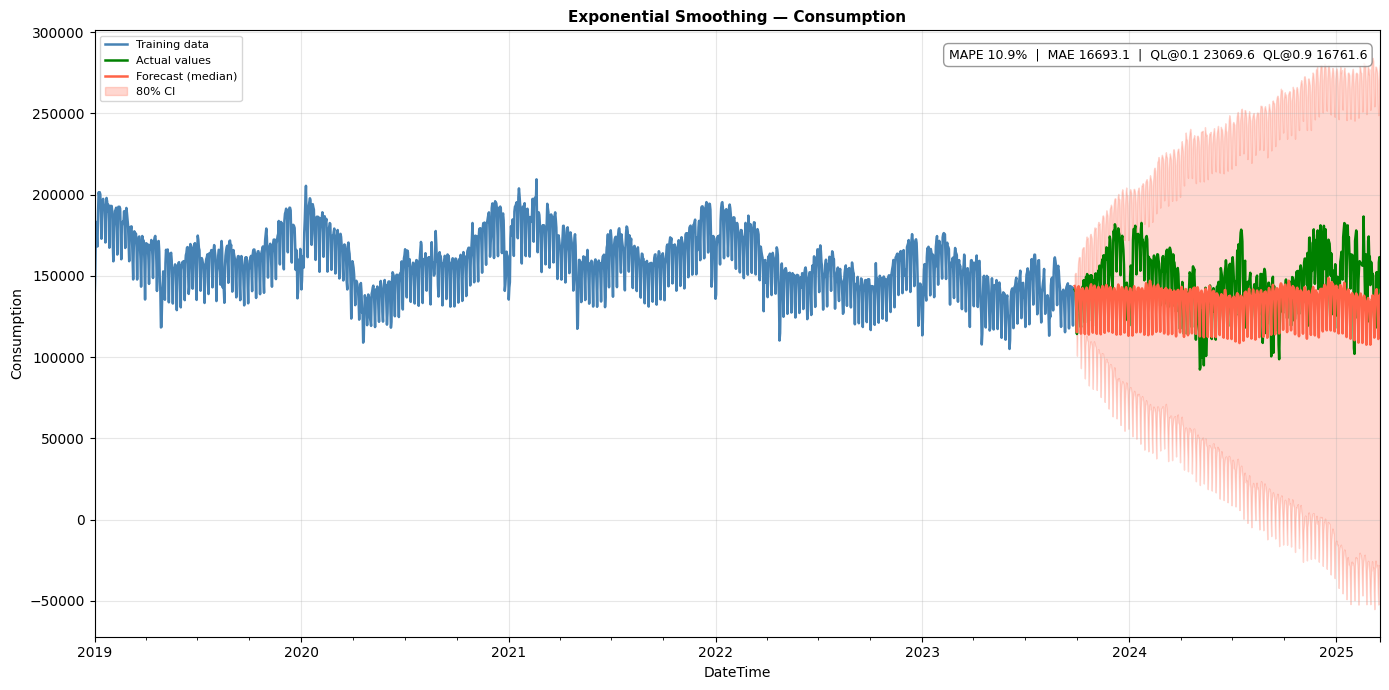

In [30]:
es_all_metrics = visualize_multi_forecast("Exponential Smoothing", es_predictions)

Sarima had better results, but this model was trained 9 times faster

Next and last model to train will be XGBoost

In [31]:
from darts.models import XGBModel

def xgb_objective(trial):
    lags = trial.suggest_int("lags", 6, 24)
    n_est = trial.suggest_int("n_estimators", 50, 300)
    depth = trial.suggest_int("max_depth", 2, 8)
    lr    = trial.suggest_float("learning_rate", 0.01, 0.3, log=True)
    sub   = trial.suggest_float("subsample", 0.6, 1.0)
    try:
        model = XGBModel(lags=lags, n_estimators=n_est, max_depth=depth,
                         learning_rate=lr, subsample=sub, random_state=42)
        model.fit(train_split)
        pred = model.predict(n=len(train_split), series=train_split)
        return mape(val_split, pred)
    except Exception:
        return float("inf")

study_xgb = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=42))
study_xgb.optimize(xgb_objective, n_trials=20, show_progress_bar=True)
print(f"\nBest MAPE on 'Consumption': {study_xgb.best_value:.2f}%")
print(f"Best params: {study_xgb.best_params}")

  0%|          | 0/20 [00:00<?, ?it/s]


Best MAPE on 'Consumption': 9.07%
Best params: {'lags': 17, 'n_estimators': 85, 'max_depth': 4, 'learning_rate': 0.03476649150592621, 'subsample': 0.7824279936868144}


In [42]:
xgb_bp = study_xgb.best_params

global_xgb = XGBModel(
    lags=xgb_bp["lags"], n_estimators=xgb_bp["n_estimators"], max_depth=xgb_bp["max_depth"],
    learning_rate=xgb_bp["learning_rate"], subsample=xgb_bp["subsample"], random_state=42,
)
global_xgb.fit(train_split)   
print(f"Global XGBModel trained on {len(train_split)} series")

xgb_predictions = global_xgb.predict(n=TEST_SIZE, series=train_split)


Global XGBModel trained on 1730 series


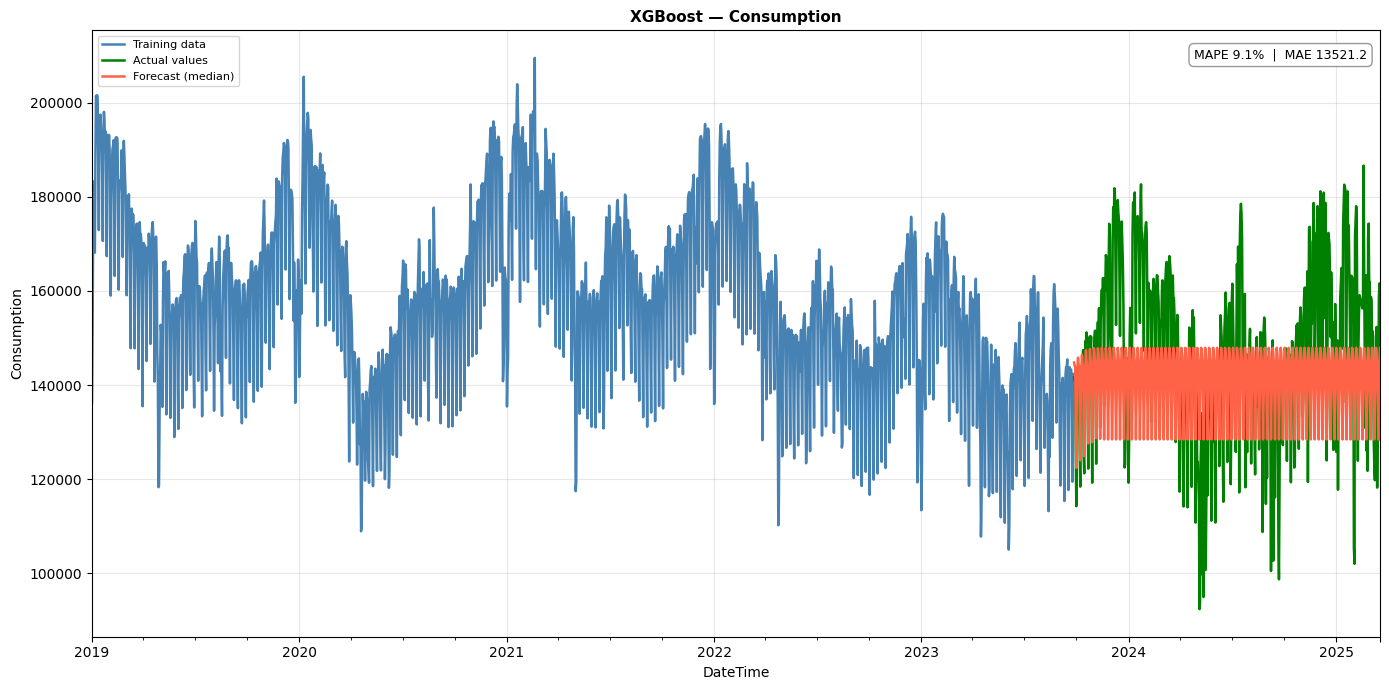

In [36]:
xgb_all_metrics = visualize_multi_forecast("XGBoost", xgb_predictions)

Those predictions are the most boring i would say, maybe because test is a whole 18month period and xgboost is better with smaller forecasts. However, now that we know how to train model, lets move to the actual task, we need to make predictions for 15, 30 and 45 days (trained on all data we have i assume)

c:\Users\vital\Desktop\DSCamp\.venv2\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\vital\Desktop\DSCamp\.venv2\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
c:\Users\vital\Desktop\DSCamp\.venv2\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\vital\Desktop\DSCamp\.venv2\Lib\site-packages\darts\metrics\metrics.py:1709: RuntimeWarning: Mean of empty slice
  return np.nanmean(
c:\Users\vital\Desktop\DSCamp\.venv2\Lib\site-packages\darts\metrics\utils.py:410: RuntimeWarning: Mean of empt

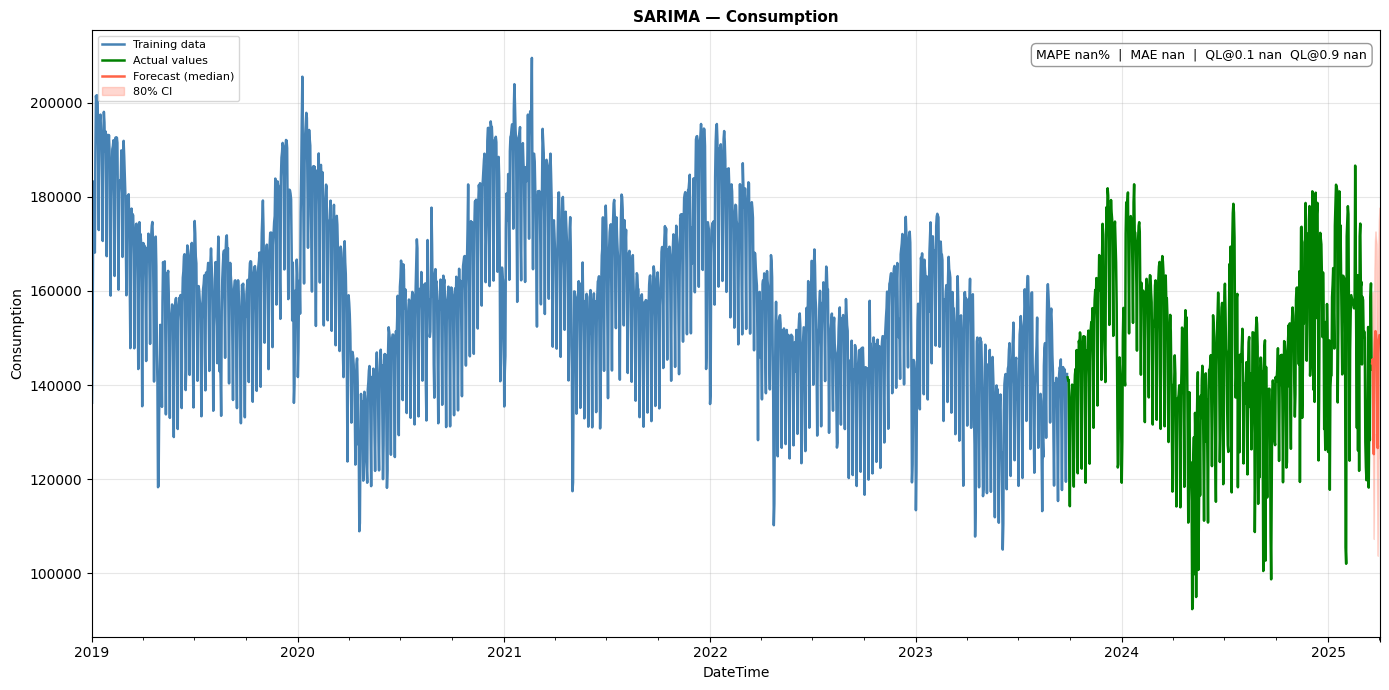

c:\Users\vital\Desktop\DSCamp\.venv2\Lib\site-packages\darts\metrics\metrics.py:1709: RuntimeWarning: Mean of empty slice
  return np.nanmean(
c:\Users\vital\Desktop\DSCamp\.venv2\Lib\site-packages\darts\metrics\utils.py:410: RuntimeWarning: Mean of empty slice
  vals = component_reduction(vals, axis=COMP_AX)
c:\Users\vital\Desktop\DSCamp\.venv2\Lib\site-packages\darts\metrics\metrics.py:400: RuntimeWarning: Mean of empty slice
  return np.nanmean(
c:\Users\vital\Desktop\DSCamp\.venv2\Lib\site-packages\darts\metrics\metrics.py:842: RuntimeWarning: Mean of empty slice
  return np.nanmean(
c:\Users\vital\Desktop\DSCamp\.venv2\Lib\site-packages\darts\metrics\metrics.py:3097: RuntimeWarning: Mean of empty slice
  return np.nanmean(


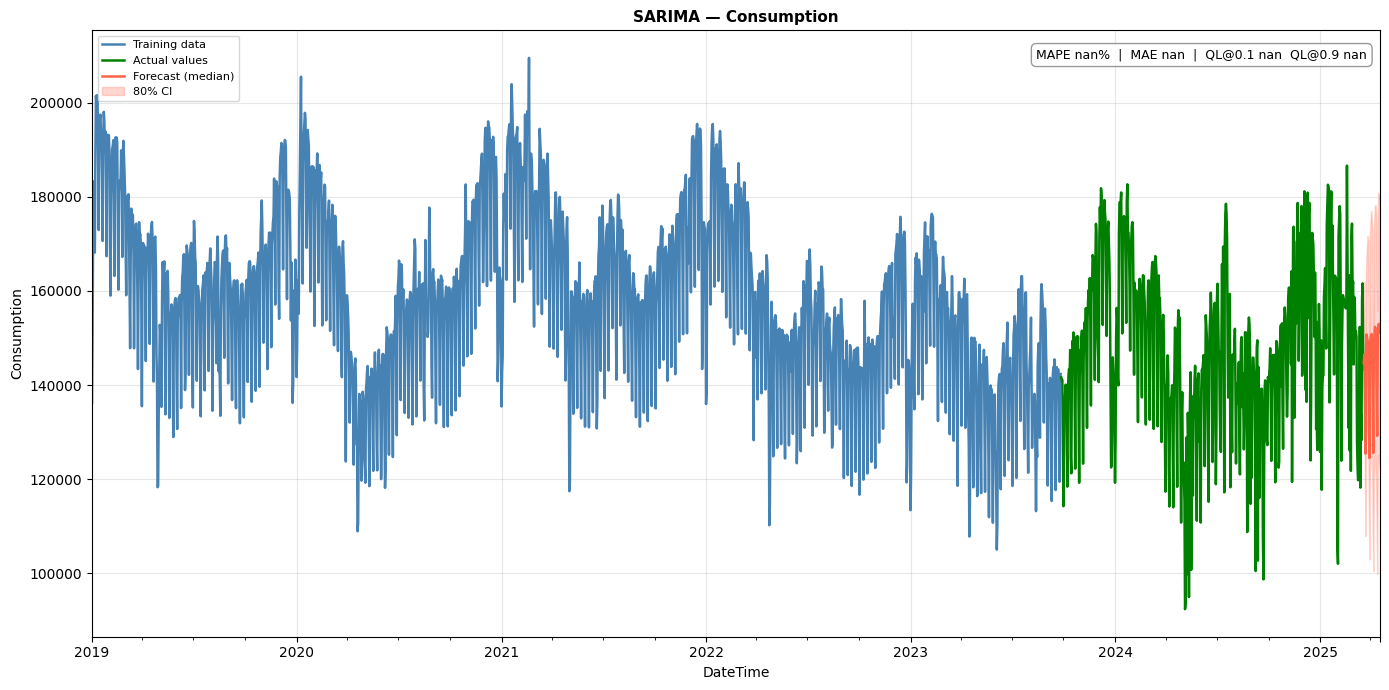

c:\Users\vital\Desktop\DSCamp\.venv2\Lib\site-packages\darts\metrics\metrics.py:1709: RuntimeWarning: Mean of empty slice
  return np.nanmean(
c:\Users\vital\Desktop\DSCamp\.venv2\Lib\site-packages\darts\metrics\utils.py:410: RuntimeWarning: Mean of empty slice
  vals = component_reduction(vals, axis=COMP_AX)
c:\Users\vital\Desktop\DSCamp\.venv2\Lib\site-packages\darts\metrics\metrics.py:400: RuntimeWarning: Mean of empty slice
  return np.nanmean(
c:\Users\vital\Desktop\DSCamp\.venv2\Lib\site-packages\darts\metrics\metrics.py:842: RuntimeWarning: Mean of empty slice
  return np.nanmean(
c:\Users\vital\Desktop\DSCamp\.venv2\Lib\site-packages\darts\metrics\metrics.py:3097: RuntimeWarning: Mean of empty slice
  return np.nanmean(


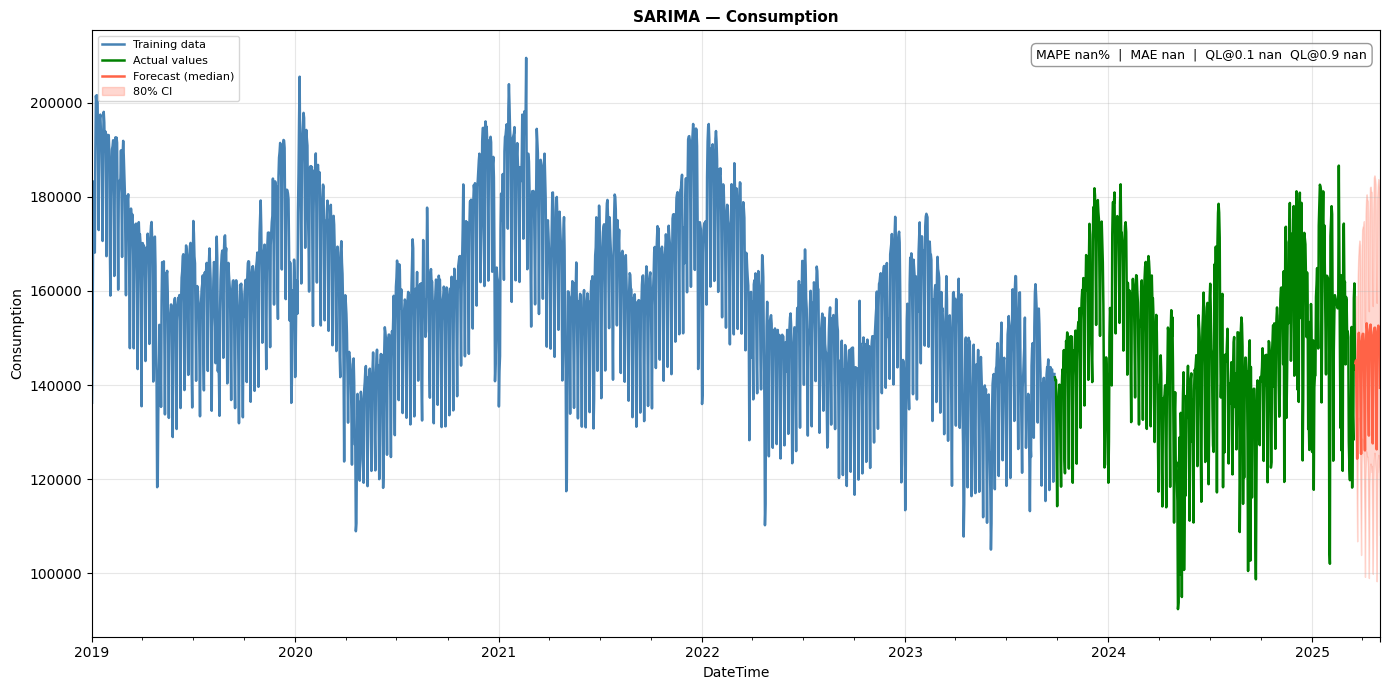

In [44]:
arima = ARIMA(p=arima_bp["p"], d=0, q=arima_bp["q"],
                  seasonal_order=(arima_bp["P"], 0, arima_bp["Q"], 7))
arima.fit(consumption_series)
for length in forecast_lengths:
    sarima_predictions = arima.predict(n=length, num_samples=500)
    sarima_all_metrics = visualize_multi_forecast("SARIMA", sarima_predictions)

The warnings are showing up because we are predicting new data, and the function expects to have data for evaluation and i'm too lazy to go implement test\no test logic

c:\Users\vital\Desktop\DSCamp\.venv2\Lib\site-packages\darts\metrics\metrics.py:1709: RuntimeWarning: Mean of empty slice
  return np.nanmean(
c:\Users\vital\Desktop\DSCamp\.venv2\Lib\site-packages\darts\metrics\utils.py:410: RuntimeWarning: Mean of empty slice
  vals = component_reduction(vals, axis=COMP_AX)
c:\Users\vital\Desktop\DSCamp\.venv2\Lib\site-packages\darts\metrics\metrics.py:400: RuntimeWarning: Mean of empty slice
  return np.nanmean(
c:\Users\vital\Desktop\DSCamp\.venv2\Lib\site-packages\darts\metrics\metrics.py:842: RuntimeWarning: Mean of empty slice
  return np.nanmean(
c:\Users\vital\Desktop\DSCamp\.venv2\Lib\site-packages\darts\metrics\metrics.py:3097: RuntimeWarning: Mean of empty slice
  return np.nanmean(


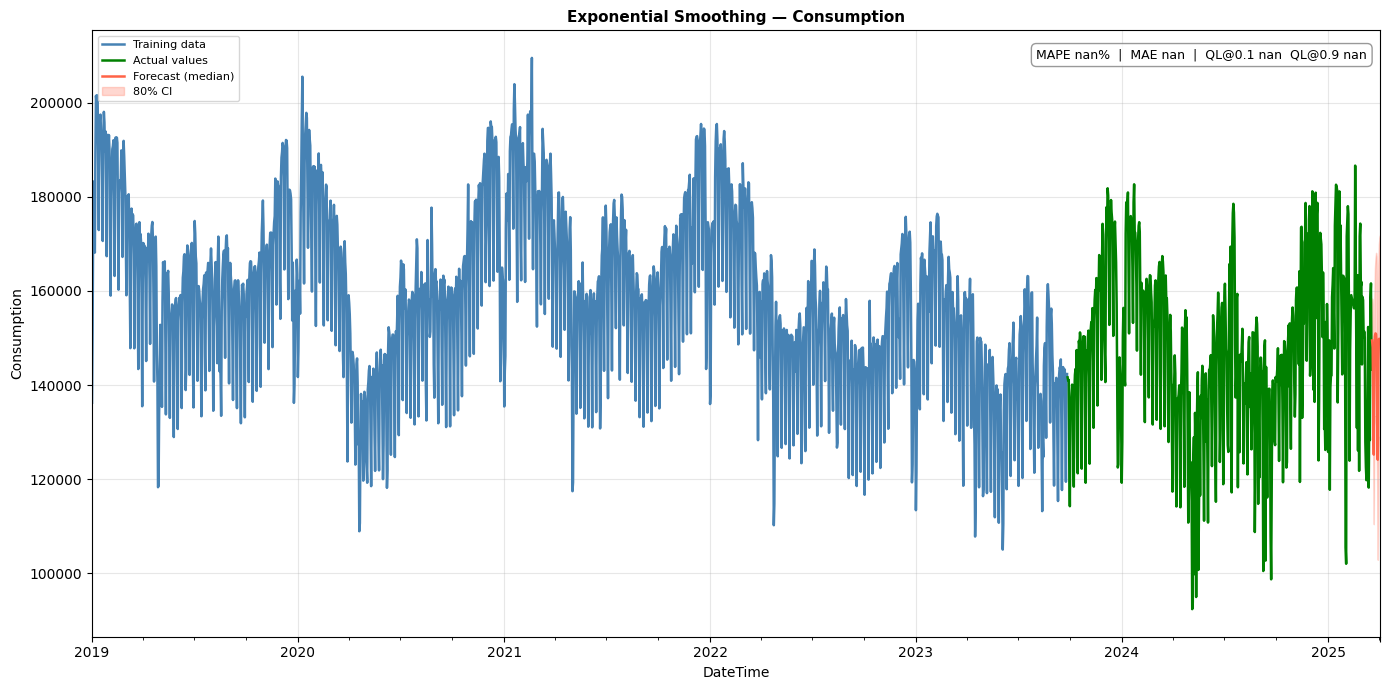

c:\Users\vital\Desktop\DSCamp\.venv2\Lib\site-packages\darts\metrics\metrics.py:1709: RuntimeWarning: Mean of empty slice
  return np.nanmean(
c:\Users\vital\Desktop\DSCamp\.venv2\Lib\site-packages\darts\metrics\utils.py:410: RuntimeWarning: Mean of empty slice
  vals = component_reduction(vals, axis=COMP_AX)
c:\Users\vital\Desktop\DSCamp\.venv2\Lib\site-packages\darts\metrics\metrics.py:400: RuntimeWarning: Mean of empty slice
  return np.nanmean(
c:\Users\vital\Desktop\DSCamp\.venv2\Lib\site-packages\darts\metrics\metrics.py:842: RuntimeWarning: Mean of empty slice
  return np.nanmean(
c:\Users\vital\Desktop\DSCamp\.venv2\Lib\site-packages\darts\metrics\metrics.py:3097: RuntimeWarning: Mean of empty slice
  return np.nanmean(


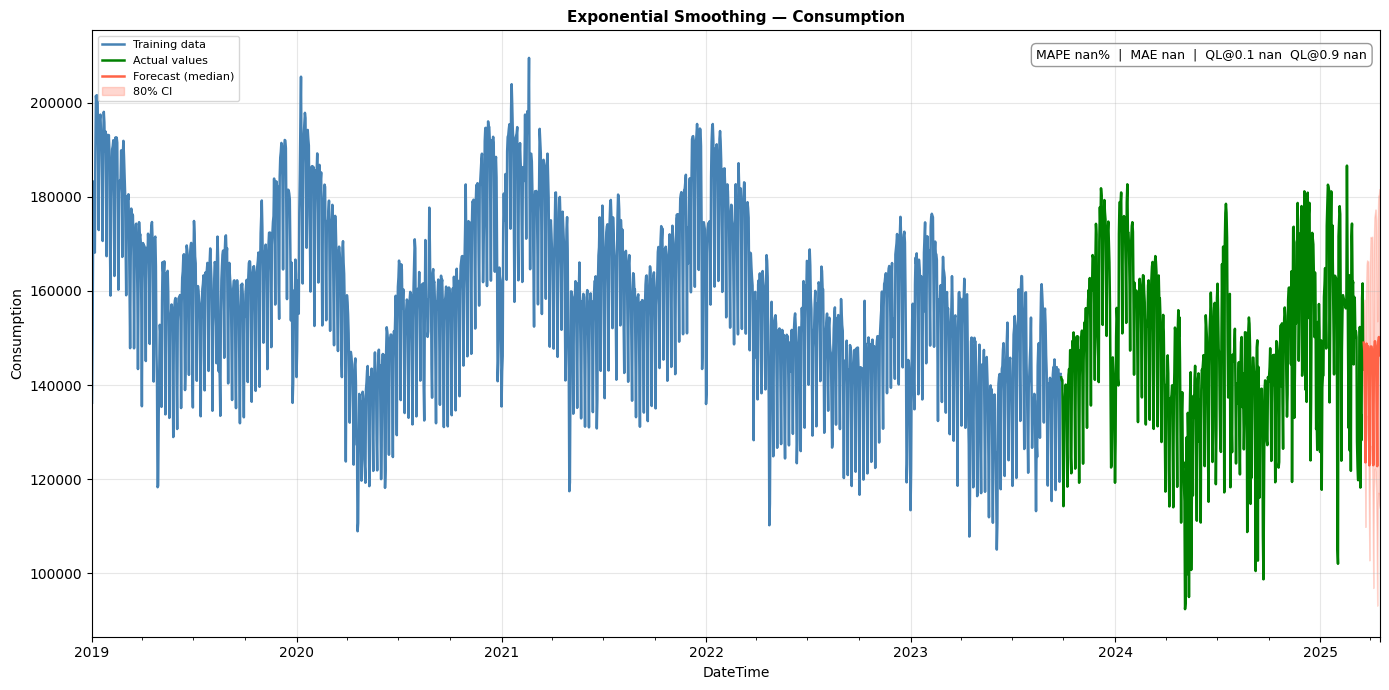

c:\Users\vital\Desktop\DSCamp\.venv2\Lib\site-packages\darts\metrics\metrics.py:1709: RuntimeWarning: Mean of empty slice
  return np.nanmean(
c:\Users\vital\Desktop\DSCamp\.venv2\Lib\site-packages\darts\metrics\utils.py:410: RuntimeWarning: Mean of empty slice
  vals = component_reduction(vals, axis=COMP_AX)
c:\Users\vital\Desktop\DSCamp\.venv2\Lib\site-packages\darts\metrics\metrics.py:400: RuntimeWarning: Mean of empty slice
  return np.nanmean(
c:\Users\vital\Desktop\DSCamp\.venv2\Lib\site-packages\darts\metrics\metrics.py:842: RuntimeWarning: Mean of empty slice
  return np.nanmean(
c:\Users\vital\Desktop\DSCamp\.venv2\Lib\site-packages\darts\metrics\metrics.py:3097: RuntimeWarning: Mean of empty slice
  return np.nanmean(


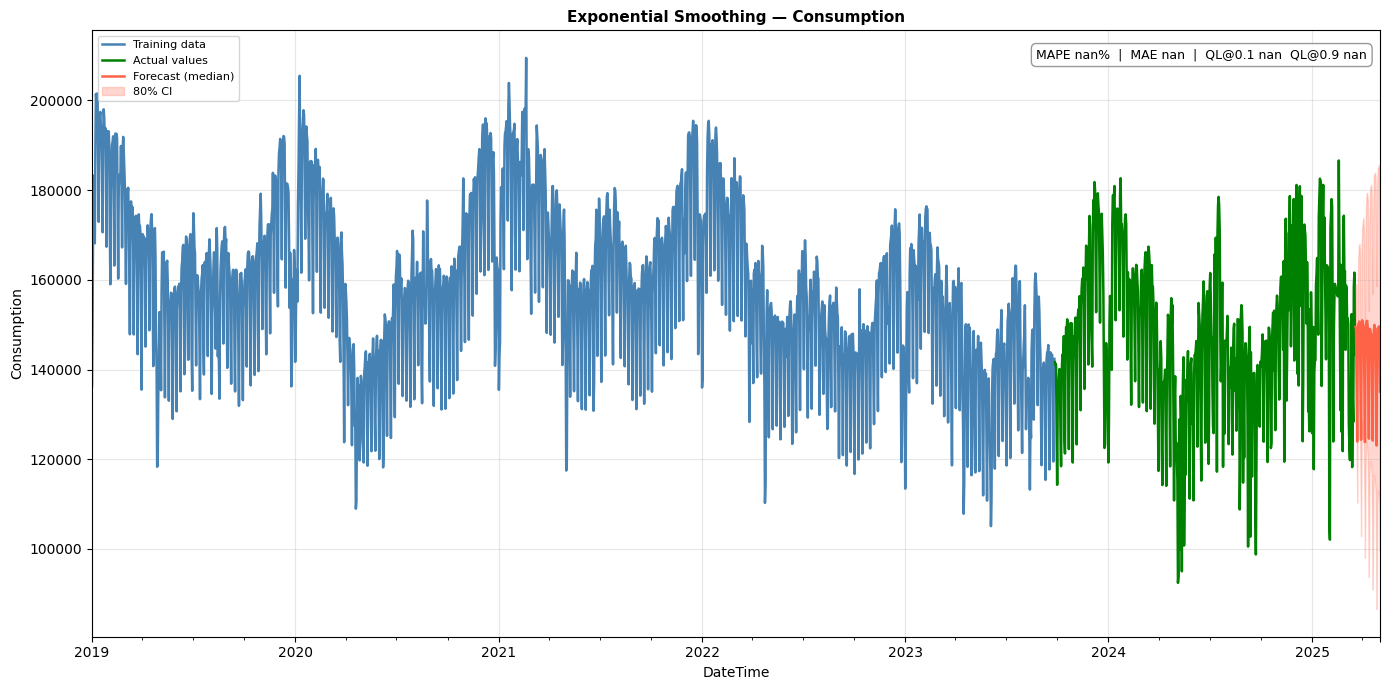

In [48]:
es_bp = study_es.best_params
es = ExponentialSmoothing(
    trend=TREND_MAP[es_bp["trend"]], seasonal=SEASONAL_MAP[es_bp["seasonal"]],
    damped=es_bp["damped"], seasonal_periods=7,
    )
es.fit(consumption_series)
for length in forecast_lengths:
    es_predictions = es.predict(n=length, num_samples=500)
    visualize_multi_forecast("Exponential Smoothing", es_predictions)
    

Global XGBModel trained on 1730 series


c:\Users\vital\Desktop\DSCamp\.venv2\Lib\site-packages\darts\metrics\metrics.py:1709: RuntimeWarning: Mean of empty slice
  return np.nanmean(
c:\Users\vital\Desktop\DSCamp\.venv2\Lib\site-packages\darts\metrics\utils.py:410: RuntimeWarning: Mean of empty slice
  vals = component_reduction(vals, axis=COMP_AX)
c:\Users\vital\Desktop\DSCamp\.venv2\Lib\site-packages\darts\metrics\metrics.py:400: RuntimeWarning: Mean of empty slice
  return np.nanmean(
c:\Users\vital\Desktop\DSCamp\.venv2\Lib\site-packages\darts\metrics\metrics.py:842: RuntimeWarning: Mean of empty slice
  return np.nanmean(


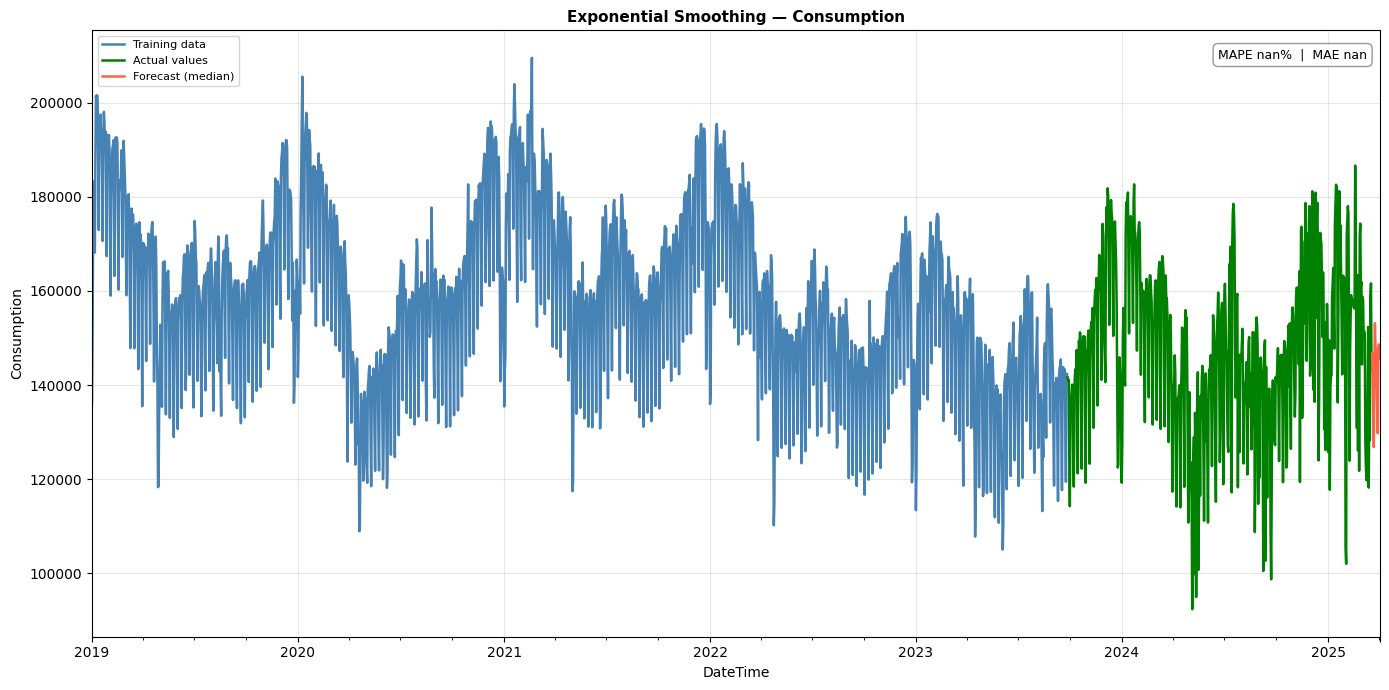

c:\Users\vital\Desktop\DSCamp\.venv2\Lib\site-packages\darts\metrics\metrics.py:1709: RuntimeWarning: Mean of empty slice
  return np.nanmean(
c:\Users\vital\Desktop\DSCamp\.venv2\Lib\site-packages\darts\metrics\utils.py:410: RuntimeWarning: Mean of empty slice
  vals = component_reduction(vals, axis=COMP_AX)
c:\Users\vital\Desktop\DSCamp\.venv2\Lib\site-packages\darts\metrics\metrics.py:400: RuntimeWarning: Mean of empty slice
  return np.nanmean(
c:\Users\vital\Desktop\DSCamp\.venv2\Lib\site-packages\darts\metrics\metrics.py:842: RuntimeWarning: Mean of empty slice
  return np.nanmean(


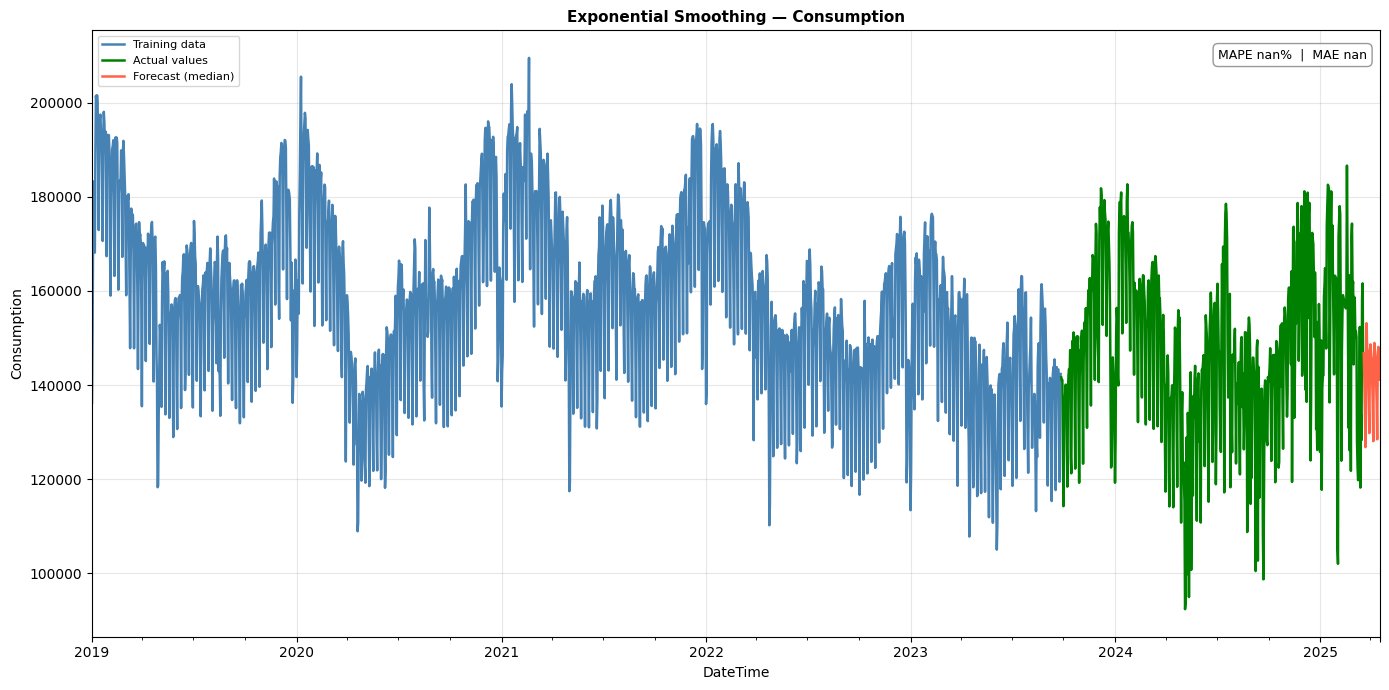

c:\Users\vital\Desktop\DSCamp\.venv2\Lib\site-packages\darts\metrics\metrics.py:1709: RuntimeWarning: Mean of empty slice
  return np.nanmean(
c:\Users\vital\Desktop\DSCamp\.venv2\Lib\site-packages\darts\metrics\utils.py:410: RuntimeWarning: Mean of empty slice
  vals = component_reduction(vals, axis=COMP_AX)
c:\Users\vital\Desktop\DSCamp\.venv2\Lib\site-packages\darts\metrics\metrics.py:400: RuntimeWarning: Mean of empty slice
  return np.nanmean(
c:\Users\vital\Desktop\DSCamp\.venv2\Lib\site-packages\darts\metrics\metrics.py:842: RuntimeWarning: Mean of empty slice
  return np.nanmean(


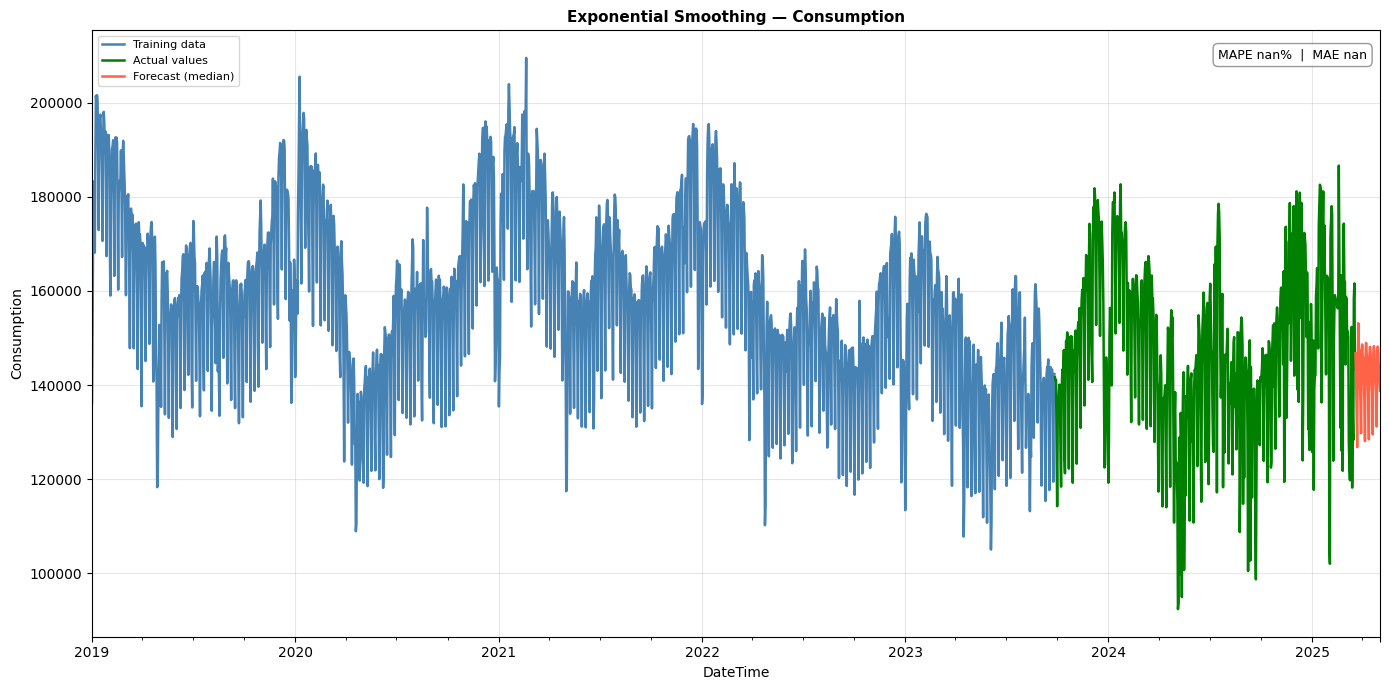

In [52]:
xgb_bp = study_xgb.best_params

global_xgb = XGBModel(
    lags=xgb_bp["lags"], n_estimators=xgb_bp["n_estimators"], max_depth=xgb_bp["max_depth"],
    learning_rate=xgb_bp["learning_rate"], subsample=xgb_bp["subsample"], random_state=42,
)
global_xgb.fit(consumption_series)   
print(f"Global XGBModel trained on {len(train_split)} series")
for length in forecast_lengths:
    xgb_predictions = global_xgb.predict(n=length, series=consumption_series)
    visualize_multi_forecast("Exponential Smoothing", xgb_predictions)